In [1]:
import sys
import os
import pandas as pd

# Thiết lập đường dẫn
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.mining.association import run_apriori

In [2]:
# Load dữ liệu đã rời rạc hóa
df = pd.read_csv("../data/processed/hotel_prepared.csv")

print("Dữ liệu đã sẵn sàng cho Mining. Kích thước:", df.shape)
print("Các cột hiện có:", df.columns.tolist())

Dữ liệu đã sẵn sàng cho Mining. Kích thước: (119390, 31)
Các cột hiện có: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'lead_time_cat']


In [3]:
# Chạy thuật toán Apriori với min_support và min_threshold (confidence)
rules = run_apriori(df, min_support=0.05, min_threshold=0.2)

# Hiển thị 10 luật có chỉ số 'lift' cao nhất
# Lift > 1 nghĩa là các sự kiện có liên quan đến nhau mạnh mẽ hơn là ngẫu nhiên
top_rules = rules.sort_values(by='lift', ascending=False).head(10)

print("TOP 10 LUẬT KẾT HỢP DẪN ĐẾN HỦY PHÒNG:")
display(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

c:\Users\PC\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


TOP 10 LUẬT KẾT HỢP DẪN ĐẾN HỦY PHÒNG:


,antecedents,consequents,support,confidence,lift
319,(deposit_type_Non Refund),"(is_canceled, market_segment_Groups, customer_...",0.066706,0.545966,8.083188
316,"(customer_type_Transient, market_segment_Groups)","(is_canceled, deposit_type_Non Refund)",0.066706,0.945058,7.784630
130,(deposit_type_Non Refund),"(is_canceled, market_segment_Groups)",0.076305,0.624529,6.163717
317,"(customer_type_Transient, deposit_type_Non Ref...","(is_canceled, market_segment_Groups)",0.066706,0.616934,6.088761
248,(deposit_type_Non Refund),"(is_canceled, lead_time_cat_Long, customer_typ...",0.051160,0.418729,4.774334
75,(deposit_type_Non Refund),"(is_canceled, lead_time_cat_Long)",0.062576,0.512168,4.343808
246,"(customer_type_Transient, deposit_type_Non Ref...","(is_canceled, lead_time_cat_Long)",0.051160,0.473158,4.012955
129,(market_segment_Groups),"(is_canceled, deposit_type_Non Refund)",0.076305,0.459846,3.787840
318,(market_segment_Groups),"(is_canceled, deposit_type_Non Refund, custome...",0.066706,0.401999,3.717921
245,"(customer_type_Transient, lead_time_cat_Long)","(is_canceled, deposit_type_Non Refund)",0.051160,0.406144,3.345490


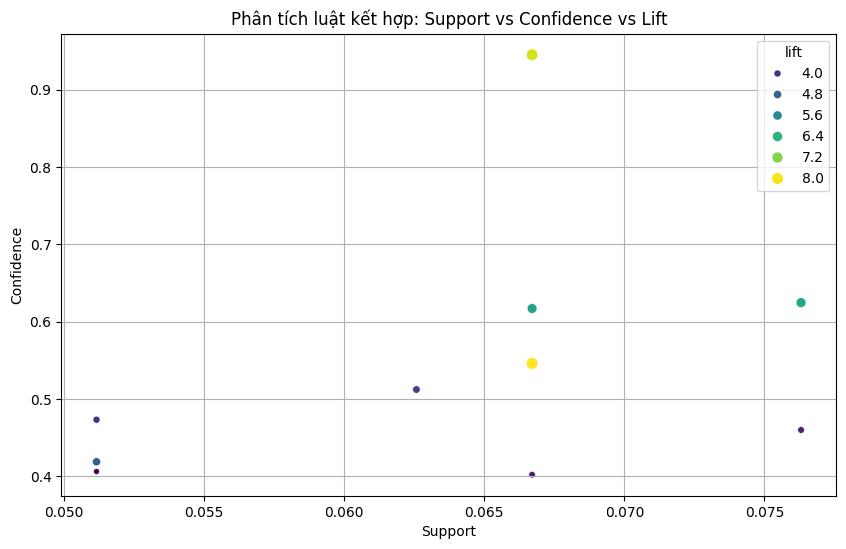

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ heatmap cho Lift của các luật kết hợp
plt.figure(figsize=(10, 6))
sns.scatterplot(data=top_rules, x='support', y='confidence', size='lift', hue='lift', palette='viridis')
plt.title('Phân tích luật kết hợp: Support vs Confidence vs Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid(True)
plt.show()